## Imports

In [1]:
import ipynbname
import os
from PIL import Image
import sys

import matplotlib.pyplot as plt 

from gvxrPython3.gVXRDataReader import *
from gvxrPython3.JSON2gVXRDataReader import *

import tifffile as tiff
import numpy as np
import cil as cil


path = ipynbname.path()
BASE = path.parents[2] 

sys.path.append(str(BASE))
from Classes.Nanotom_class.NanotomXCT import NanotomXCT
from Classes.Comparisor_class.xct_comparisor import *
path_data = BASE / "Data/Lego_minifigure"
path_results = BASE / "Results/Lego_minifigure"

if not os.path.exists(path_results):
    os.makedirs(path_results)


c:\Users\SEFAHLGRENK\AppData\Local\miniconda3\envs\dev_env\Lib\site-packages\dxchange\__init__.py:63: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Define parameters of scan
It is only possible to reconstruct a smaller volume, so an aqusition using 100 pixel rows are used. All other parameters are set as the experimental XCT scan

In [2]:
SDD = 399.99865000 # Source-Detector distance 
SSD = 95.99990000 # Source-Sample distance 

voltage_kV = 60
current_mA = 0.3 
exposure_time_s = 0.375013 

# Number of pixels 
xPixels = 1300
yPixels = 100 # original height is 2042 pixels

nbr_projections = 2042

scaling = 1 
lenght_unit = "mm"

tom = NanotomXCT(length_unit=lenght_unit, scaling=scaling, output_path=path_results)
tom.set_distances(SSD=SSD, SDD=SDD)
tom.setup_detector(xPixels=xPixels, yPixels=yPixels)
tom.setup_source(voltage_kV=voltage_kV, current_mA=current_mA, exposure_time_s=exposure_time_s, noise=True)

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 39.999864959716795
594511367.3923327  photons / cm^2
59451.13673923326  photons / pixel


In [3]:
# Body
mixture_body, mf_body = ["C","H","N"], [0.871, 0.081, 0.048]
density_body = 1.04
path_STL_body_simpl = path_data / "Meshes/MeshBodyfastSimplified.stl"


# Hands 
mixture_hands, mf_hands = ["C", "H", "O"], [0.4, 0.067, 0.533]
density_hands = 1.41
path_STL_hands_simpl = path_data / "Meshes/Mesh from Hands fastsimplified.stl"


# Print
mixture_print, mf_print = ["Ti", "O"], [0.3, 0.7]
density_print = 0.6
path_STL_print_simpl = path_data / "Meshes/Mesh from Print fastsimplified.stl"


tom.addMesh(label="Body", path=path_STL_body_simpl, density=density_body, mixture= mixture_body, mass_fraction=mf_body)
tom.addMesh(label="Hands", path=path_STL_hands_simpl, density=density_hands, mixture=mixture_hands, mass_fraction=mf_hands)
tom.addMesh(label="Print", path=path_STL_print_simpl, density=density_body, mixture=mixture_body, mass_fraction=mf_body)
           

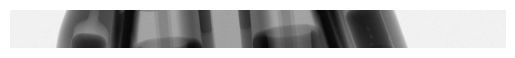

In [4]:
img = tom.compute2D()

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
FFC = 0
json = tom.computeCTAcquisition(nbr_projections, FFC=FFC, label="")

In [ ]:
# If reconstructing directly after aquisition
filter = "shepp-logan"
recon = tom.computeReconstruction(tom.CT_path, json, filter=filter)

In [6]:
# reconstruct from defined path 
filter = "shepp-logan"
path_sim = path_results /"CT-Scans/CT_2042_yPixels=100_FFC=0"
json = path_results /"CT-Scans/CT_2042_yPixels=100_FFC=0/simulation-2042.json"
recon = tom.computeReconstruction(path_sim, json_fname=json, filter = filter)


[1300, 100]
[0.01, 0.01]
FDK recon

Input Data:
	angle: 2042
	vertical: 100
	horizontal: 1300

Reconstruction Volume:
	vertical: 100
	horizontal_y: 1300
	horizontal_x: 1300

Reconstruction Options:
	Backend: tigre
	Filter: shepp-logan
	Filter cut-off frequency: 1.0
	FFT order: 12
	Filter_inplace: False

FDK-reconstruction complete! Execution time: 9.4285 s


Compare center vertical slice in simulated and experimental reconstructions:

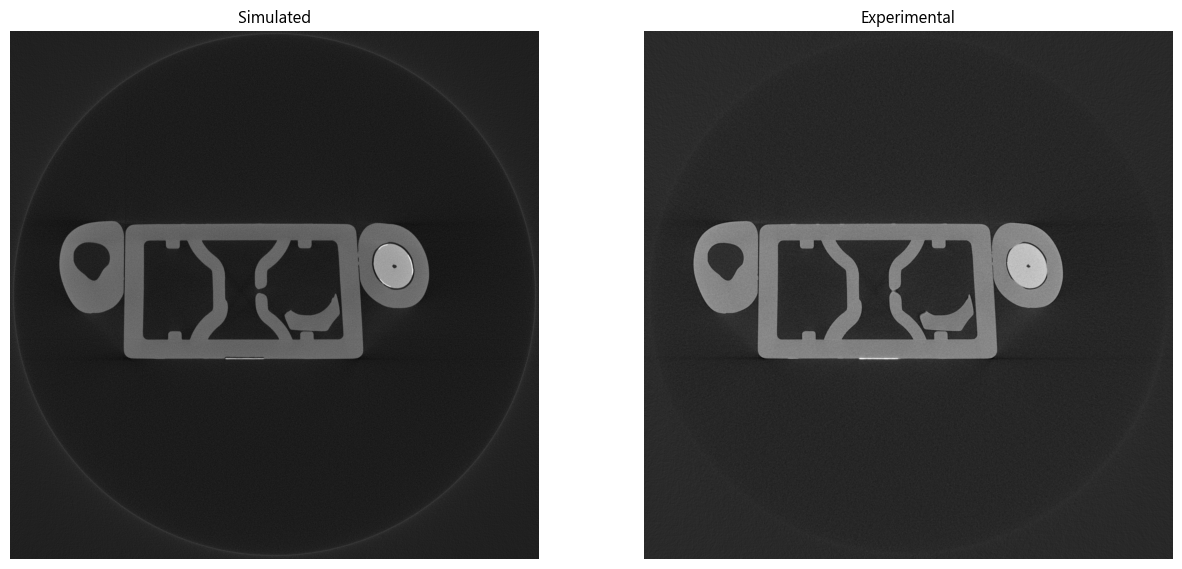

In [10]:
path_real_slice = path_data /"Slices/vertical_slice1024.tif"
path_simulated_stack = path_results /"CT-Scans/CT_2048_yPixels=100_FFC=0/Tiff-Stack_Filter=shepp-logan.tif"


sim_vol = tiff.imread(path_simulated_stack)
sim_slice = sim_vol[50]

sim_slice = np.flipud(sim_slice)  
real_slice = np.array(Image.open(path_real_slice), dtype=np.single) 

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(sim_slice, cmap='gray')
plt.axis('off')
plt.title('Simulated')

plt.subplot(1,2,2)
plt.imshow(real_slice, cmap='gray')
plt.axis('off')
plt.title('Experimental')
plt.show()
